# Notebook 03 — Scoring, Affordability & Regression
## The 15-Minute Shanghai Project · Track C — Affordability

Turns the per-hexagon accessibility (notebook 02) into (i) a transparent **criteria scorecard**, (ii) the **affordability
cross-analysis** at the heart of Track C — adding **🏠 affordable housing** as an explicit seventh criterion — and (iii) a
**hedonic regression** testing whether 15-minute access is *capitalised into housing prices* (the equity question of
Weng et al., 2019).

**Research question.** *Is 15-minute access in Shanghai a privilege of the wealthy, or do "accessible-and-affordable"
corridors exist?*

## 1. Setup & load

In [1]:
import sys, warnings
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent / "src"))
import numpy as np, pandas as pd, geopandas as gpd, h3
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf
from config import DATA_CLEAN, OUTPUTS, H3_RES, CRITERIA, AFFORDABLE_LABEL
from geo_utils import types_per_cell
warnings.filterwarnings("ignore")
WGS84 = "EPSG:4326"
CRIT = list(CRITERIA)

hexes = gpd.read_parquet(DATA_CLEAN / "hexes.parquet")
prices = gpd.read_parquet(DATA_CLEAN / "prices.parquet")
poi = gpd.read_parquet(DATA_CLEAN / "poi.parquet")
transit = gpd.read_parquet(DATA_CLEAN / "transit.parquet")
print(f"Hexagones: {len(hexes):,} (res {H3_RES}) | Points de prix: {len(prices):,}")
print("Critères d'accès:", [CRITERIA[k]["label"] for k in CRIT])

Hexagones: 1,869 (res 7) | Points de prix: 27,471
Critères d'accès: ['🛒 Courses alimentaires', '🏥 Santé de proximité', '🏫 École', '🚉 Transport en commun', '🏦 Services essentiels', '🌳 Parc / sport']


## 2. The accessibility scorecard
Each hexagon already carries, from notebook 02, a boolean per criterion (`acc_*`), a **baseline score** (0–6) and a
weighted **access index** (0–100, walk = 1.0 / bike-only = 0.5). We display the criteria scorecard so the meaning of each
score is explicit.

In [2]:
scorecard = pd.DataFrame({
    "Critère": [CRITERIA[k]["label"] for k in CRIT],
    "Définition": [CRITERIA[k]["desc"] for k in CRIT],
    "% hexagones desservis": [round(100*hexes[f"acc_{k}"].mean(), 1) for k in CRIT],
})
print(scorecard.to_string(index=False))
print(f"\nScore baseline moyen : {hexes['baseline_score'].mean():.2f}/6 | "
      f"Indice d'accessibilité moyen : {hexes['access_index'].mean():.1f}/100")

               Critère                                                                                               Définition  % hexagones desservis
🛒 Courses alimentaires Supermarché, supérette ou marché alimentaire à ≤15 min (les courses du quotidien — pas les restaurants).                   91.0
  🏥 Santé de proximité                                                   Hôpital, clinique, dispensaire ou pharmacie à ≤15 min.                   85.9
               🏫 École                                      Crèche, école, collège ou lycée à ≤15 min (données scolaires 2026).                   71.3
 🚉 Transport en commun                              Station de métro ou arrêt de bus à ≤15 min (accès à l'emploi sans voiture).                   92.2
 🏦 Services essentiels                                                            Banque, poste ou équipement public à ≤15 min.                   86.8
        🌳 Parc / sport                                                  Parc, espace vert, ter

## 3. Aggregate housing prices to hexagons
Each price point is binned to its H3 cell; hexagon price = **median ¥/m²**.

In [3]:
pts = prices.geometry.representative_point()
prices = prices.assign(lng=pts.x.values, lat=pts.y.values)
prices["cell"] = [h3.latlng_to_cell(la, lo, H3_RES) for la, lo in zip(prices["lat"], prices["lng"])]
hexes["price_per_m2"] = hexes["cell"].map(prices.groupby("cell")["price_per_m2"].median())
hexes["n_price"] = hexes["cell"].map(prices.groupby("cell").size()).fillna(0).astype(int)
cov = hexes["price_per_m2"].notna().mean()
print(f"Hexagones avec prix : {hexes['price_per_m2'].notna().sum():,} ({100*cov:.0f}%) "
      f"— la maille res {H3_RES} améliore la couverture.")
print(hexes["price_per_m2"].describe().round(0).to_string())

Hexagones avec prix : 874 (47%) — la maille res 7 améliore la couverture.
count       874.0
mean      36154.0
std       21286.0
min        2645.0
25%       18905.0
50%       31894.0
75%       48391.0
max      143022.0


## 4. 🏠 Affordable housing — the 7th criterion, and the Track C typology
We add **affordable housing** as an explicit criterion: a hexagon is *affordable* if its median price is **below the city
median**. Crossing accessibility × affordability at their medians gives four neighbourhood types; the target is
**Accessible & affordable**. The continuous **value score** = (access percentile − price percentile).

In [4]:
pmed = hexes["price_per_m2"].median()
hexes["affordable"] = hexes["price_per_m2"] <= pmed          # 🏠 critère abordabilité
print(f"Seuil 'abordable' = prix médian = {pmed:,.0f} ¥/m²")

hd = hexes.dropna(subset=["price_per_m2"]).copy()
amed = hd["access_index"].median()
def classify(r):
    acc_hi, aff = r["access_index"] >= amed, r["price_per_m2"] <= pmed
    if acc_hi and aff:     return "Accessible & abordable"
    if acc_hi and not aff: return "Privilégié (cher)"
    if not acc_hi and aff: return "Abordable mais enclavé"
    return "Enclavé & cher"
hexes["afford_type"] = hd.apply(classify, axis=1).reindex(hexes.index)

hexes["access_pct"] = hexes["access_index"].rank(pct=True) * 100
hexes.loc[hd.index, "price_pct"] = hd["price_per_m2"].rank(pct=True) * 100
hexes["value_score"] = (hexes["access_pct"] - hexes["price_pct"]).round(1)
# score complet /7 = 6 critères d'accès + logement abordable
hexes["score_complet_7"] = hexes["baseline_score"] + hexes["affordable"].fillna(False).astype(int)
print("\nTypologie:"); print(hexes["afford_type"].value_counts().to_string())

Seuil 'abordable' = prix médian = 31,894 ¥/m²

Typologie:
afford_type
Privilégié (cher)         337
Accessible & abordable    234
Abordable mais enclavé    203
Enclavé & cher            100


## 5. Regression — is access capitalised into price?
Hedonic OLS on Anjuke listings; we add the hexagon `access_index` to the prior price~metro-distance model.

In [5]:
anj = prices[prices["source"] == "anjuke"].copy()
anj["access_index"] = anj["cell"].map(hexes.set_index("cell")["access_index"])
anj = anj.dropna(subset=["price_per_m2", "dist_metro_m", "access_index"])
anj["log_price"] = np.log(anj["price_per_m2"]); anj["metro_km"] = anj["dist_metro_m"]/1000
m1 = smf.ols("log_price ~ metro_km", anj).fit()
m2 = smf.ols("log_price ~ metro_km + access_index", anj).fit()
m3 = smf.ols("log_price ~ metro_km + access_index + C(adname)", anj).fit()
print(f"n = {len(anj):,} logements Anjuke\n")
print(f"{'Modèle':<30}{'R²':>8}{'β metro_km':>13}{'β access':>11}")
for name, m in [("1. prix~métro", m1), ("2. +accessibilité", m2), ("3. +district (FE)", m3)]:
    print(f"{name:<30}{m.rsquared:>8.3f}{m.params.get('metro_km', float('nan')):>13.4f}"
          f"{m.params.get('access_index', float('nan')):>11.4f}")
print("\nModèle 2 :"); print(m2.summary().tables[1])

n = 9,740 logements Anjuke

Modèle                              R²   β metro_km   β access
1. prix~métro                    0.142      -0.1808        nan
2. +accessibilité                0.168      -0.1591     0.0117
3. +district (FE)                0.570      -0.0760     0.0026

Modèle 2 :
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept        9.7564      0.068    144.379      0.000       9.624       9.889
metro_km        -0.1591      0.005    -34.539      0.000      -0.168      -0.150
access_index     0.0117      0.001     17.212      0.000       0.010       0.013


## 6. Maps — price, typology, value

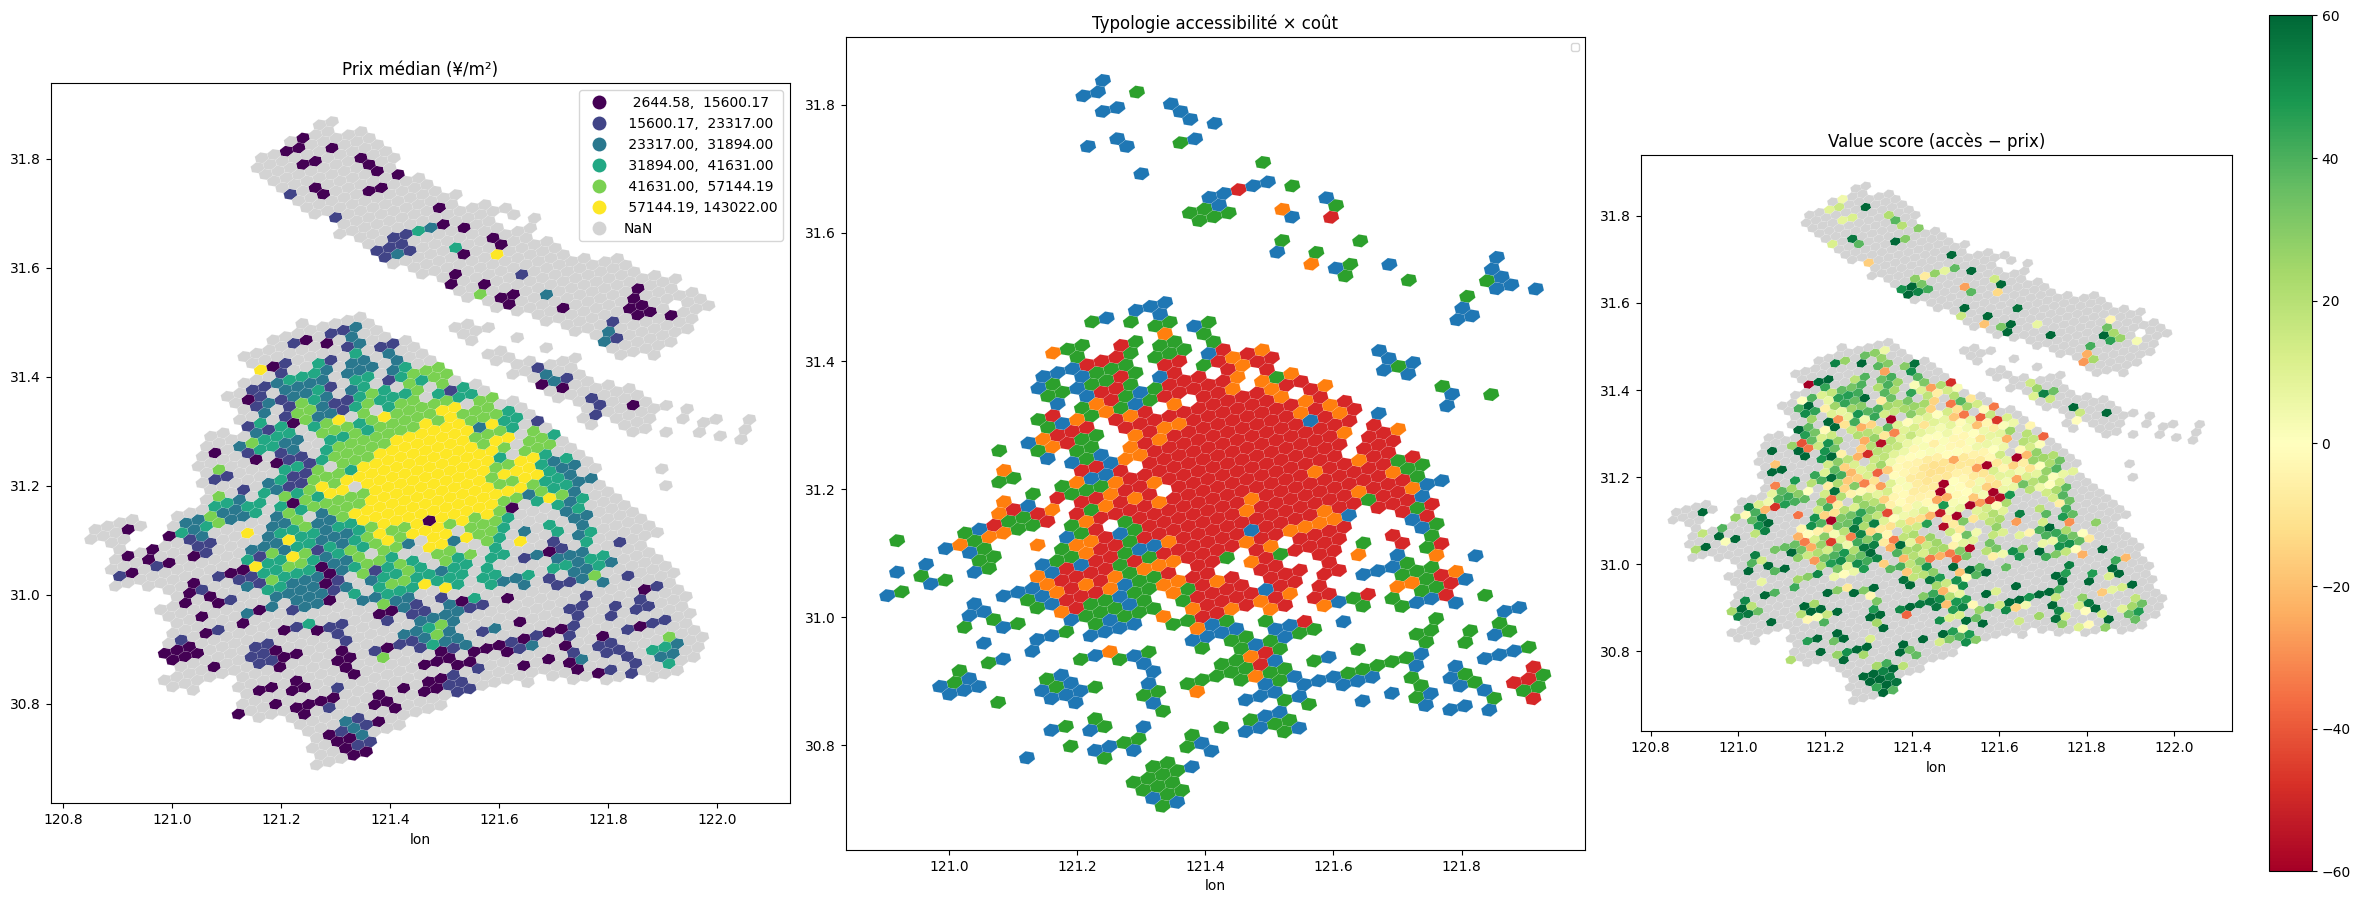

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(24, 9))
hexes.plot(column="price_per_m2", cmap="viridis", scheme="quantiles", k=6, legend=True,
           linewidth=0.05, edgecolor="white", ax=axes[0], missing_kwds={"color": "lightgrey"})
axes[0].set_title("Prix médian (¥/m²)")
colors = {"Accessible & abordable": "#2ca02c", "Privilégié (cher)": "#d62728",
          "Abordable mais enclavé": "#1f77b4", "Enclavé & cher": "#ff7f0e"}
for t, c in colors.items():
    sub = hexes[hexes["afford_type"] == t]
    if len(sub): sub.plot(color=c, linewidth=0.05, edgecolor="white", ax=axes[1], label=t)
axes[1].legend(fontsize=8); axes[1].set_title("Typologie accessibilité × coût")
hexes.plot(column="value_score", cmap="RdYlGn", vmin=-60, vmax=60, legend=True,
           linewidth=0.05, edgecolor="white", ax=axes[2], missing_kwds={"color": "lightgrey"})
axes[2].set_title("Value score (accès − prix)")
for ax in axes: ax.set_aspect("equal"); ax.set_xlabel("lon")
plt.tight_layout(); plt.show()

## 7. "Where to live" — accessible-and-affordable corridors

In [7]:
best = hexes[hexes["afford_type"] == "Accessible & abordable"].sort_values("value_score", ascending=False)
print(f"Corridors 'accessible & abordable' : {len(best):,} hexagones\n")
print(best[["cell", "access_index", "price_per_m2", "value_score", "score_complet_7"]].head(12).to_string(index=False))

Corridors 'accessible & abordable' : 234 hexagones

           cell  access_index  price_per_m2  value_score  score_complet_7
873099d5bffffff         100.0   9302.000000         85.7                7
87309d6a9ffffff         100.0   9345.000000         85.5                7
873098652ffffff         100.0   9976.231002         85.3                7
873099cecffffff         100.0  10057.874020         85.0                7
873099d42ffffff         100.0  10260.344476         84.6                7
87309bc64ffffff         100.0  10392.000000         84.1                7
873099d2cffffff         100.0  10517.000000         83.9                7
87309b99dffffff         100.0  11343.000000         82.3                7
87309bd48ffffff         100.0  11384.500000         82.2                7
87309bd66ffffff         100.0  11428.571429         82.0                7
87309ba12ffffff         100.0  11430.000000         81.8                7
87309b8b5ffffff         100.0  11610.000000         81.3    

## 8. Specific POI types per hexagon
For each criterion, list the concrete types of places present (e.g. *supermarché, épicerie, marché*) — surfaced in the app tooltip so the user sees exactly what is reachable.

In [8]:
types = types_per_cell(poi, transit, CRITERIA, H3_RES)
for k in CRIT:
    hexes[f"types_{k}"] = hexes["cell"].map(types[k]).fillna("")
print("Exemples de types (hexagone le mieux desservi) :")
ex = hexes.sort_values("access_index", ascending=False).iloc[0]
for k in CRIT:
    print(f"  {CRITERIA[k]['label']:26} {ex[f'types_{k}'] or '—'}")

Exemples de types (hexagone le mieux desservi) :
  🛒 Courses alimentaires     épicerie, marché de fruits, supermarché
  🏥 Santé de proximité       pharmacie, dentiste, clinique
  🏫 École                    maternelle, collège/lycée, école primaire
  🚉 Transport en commun      bus, métro
  🏦 Services essentiels      toilettes publiques, banque, services financiers
  🌳 Parc / sport             sport, salle de sport, divertissement


## 9. Export enriched grid

In [9]:
keep = (["cell", "clat", "clng", "baseline_score", "n_walk", "n_bike", "access_index",
         "price_per_m2", "n_price", "affordable", "afford_type", "value_score", "score_complet_7"]
        + [f"acc_{k}" for k in CRIT] + [f"types_{k}" for k in CRIT])
out = hexes[keep + ["geometry"]].copy()
out.to_file(OUTPUTS / "hexes.geojson", driver="GeoJSON")
out.to_parquet(DATA_CLEAN / "hexes_scored.parquet")
for f in [OUTPUTS / "hexes.geojson", DATA_CLEAN / "hexes_scored.parquet"]:
    print(f"  {f.name:24} {f.stat().st_size/1e6:6.2f} MB | {len(out):,} hexagones")
print("\nColonnes:", list(out.columns))

  hexes.geojson              1.97 MB | 1,869 hexagones
  hexes_scored.parquet       0.28 MB | 1,869 hexagones

Colonnes: ['cell', 'clat', 'clng', 'baseline_score', 'n_walk', 'n_bike', 'access_index', 'price_per_m2', 'n_price', 'affordable', 'afford_type', 'value_score', 'score_complet_7', 'acc_courses', 'acc_sante', 'acc_ecole', 'acc_transport', 'acc_services', 'acc_parc_sport', 'types_courses', 'types_sante', 'types_ecole', 'types_transport', 'types_services', 'types_parc_sport', 'geometry']
